In [3]:
import os
train_dir = os.path.join('DevanagariHandwrittenCharacterDataset', 'Train')
test_dir = os.path.join('DevanagariHandwrittenCharacterDataset', 'Test')


In [4]:
# Total number of classes in the dataset
classes = os.listdir(train_dir)
print("Length of the list : ",len(classes))
classes

Length of the list :  46


['character_10_yna',
 'character_11_taamatar',
 'character_12_thaa',
 'character_13_daa',
 'character_14_dhaa',
 'character_15_adna',
 'character_16_tabala',
 'character_17_tha',
 'character_18_da',
 'character_19_dha',
 'character_1_ka',
 'character_20_na',
 'character_21_pa',
 'character_22_pha',
 'character_23_ba',
 'character_24_bha',
 'character_25_ma',
 'character_26_yaw',
 'character_27_ra',
 'character_28_la',
 'character_29_waw',
 'character_2_kha',
 'character_30_motosaw',
 'character_31_petchiryakha',
 'character_32_patalosaw',
 'character_33_ha',
 'character_34_chhya',
 'character_35_tra',
 'character_36_gya',
 'character_3_ga',
 'character_4_gha',
 'character_5_kna',
 'character_6_cha',
 'character_7_chha',
 'character_8_ja',
 'character_9_jha',
 'digit_0',
 'digit_1',
 'digit_2',
 'digit_3',
 'digit_4',
 'digit_5',
 'digit_6',
 'digit_7',
 'digit_8',
 'digit_9']

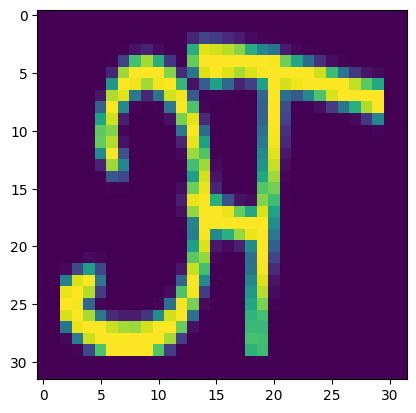

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load image
img = mpimg.imread('DevanagariHandwrittenCharacterDataset/Train/character_10_yna/10542.png')

# Display image
plt.imshow(img)
plt.show()


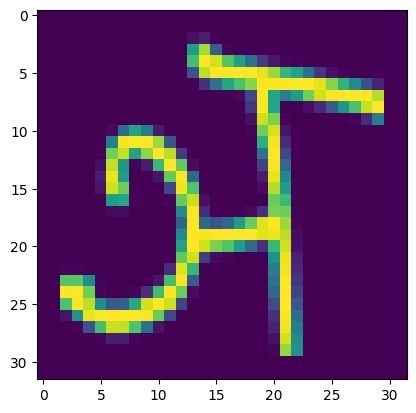

In [6]:
# Load image
img = mpimg.imread('DevanagariHandwrittenCharacterDataset/Train/character_10_yna/10576.png')

# Display image
plt.imshow(img)
plt.show()


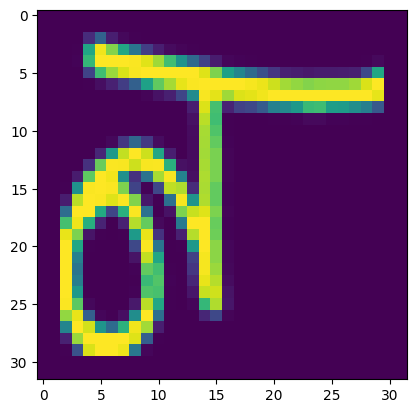

In [7]:
# Load image
img = mpimg.imread('DevanagariHandwrittenCharacterDataset/Train/character_20_na/11061.png')

# Display image
plt.imshow(img)
plt.show()


In [8]:
FOLDER_TO_HINDI = {
    'character_10_yna':  'ञ', 'character_11_ta':   'ट', 'character_12_thaa': 'ठ',
    'character_13_daa':  'ड', 'character_14_dhaa': 'ढ', 'character_15_ana':  'ण',
    'character_16_tabla': 'त', 'character_17_tha':  'थ', 'character_18_da':   'द',
    'character_19_dha':  'ध', 'character_1_ka':    'क', 'character_20_na':   'न',
    'character_21_pa':   'प', 'character_22_pha':  'फ', 'character_23_ba':   'ब',
    'character_24_bha':  'भ', 'character_25_ma':   'म', 'character_26_yaw':  'य',
    'character_27_ra':   'र', 'character_28_la':   'ल', 'character_29_va':   'व',
    'character_2_kha':   'ख', 'character_30_shaw': 'श', 'character_31_shha': 'ष',
    'character_32_sa':   'स', 'character_33_ha':   'ह', 'character_34_shra': 'क्ष',
    'character_35_tra':  'त्र', 'character_36_gya':  'ज्ञ', 'character_3_ga':    'ग',
    'character_4_gha':   'घ', 'character_5_kna':   'ङ', 'character_6_cha':   'च',
    'character_7_chha':  'छ', 'character_8_ja':    'ज', 'character_9_jha':   'झ',
    'digit_0': '०', 'digit_1': '१', 'digit_2': '२', 'digit_3': '३', 'digit_4': '४',
    'digit_5': '५', 'digit_6': '६', 'digit_7': '७', 'digit_8': '८', 'digit_9': '९',
}


In [9]:
hindi_character = [FOLDER_TO_HINDI[name] for name in training_dataset.class_names]


In [10]:
# Creating Batches

#Import the data from the directories, then transform them into batches
training_dataset = image_dataset_from_directory(directory=train_dir,
                                                image_size=(32,32),
                                                batch_size=32,
                                                label_mode='categorical')

testting_dataset = image_dataset_from_directory(directory=test_dir,
                                                image_size=(32,32),
                                                batch_size=32,
                                                label_mode='categorical',
                                                shuffle=False)

Found 78200 files belonging to 46 classes.
Found 13800 files belonging to 46 classes.


In [16]:
# Architecture of the CNN
model_1 = tf.keras.Sequential([
    tf.keras.Sequential([layers.Rescaling(1./255)]),

    # Layer1
    layers.Conv2D(filters=6, kernel_size=(5, 5), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.AveragePooling2D(pool_size=(2, 2)),

    # Layer2
    layers.Conv2D(filters=16, kernel_size=(5, 5), activation='relu'),
    layers.BatchNormalization(),
    layers.AveragePooling2D(pool_size=(2, 2)),

    # Flatten the array
    layers.Flatten(),

    # Fully Connected Layer 1
    layers.Dense(120, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Adjust dropout rate as needed

    # Fully Connected Layer 2
    layers.Dense(84, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Fully Connected Layer 3
    layers.Dense(len(classes), activation='softmax')
])


In [12]:
# Compile Model
model_1.compile(loss = 'categorical_crossentropy',
                optimizer = 'adam',
                metrics = ['accuracy'])

In [13]:
# Model fitting on the loaded dataset
model_1_history = model_1.fit(training_dataset,
                              validation_data = testting_dataset,
                        epochs = 10 ,)

Epoch 1/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 52s 20ms/step - accuracy: 0.3909 - loss: 2.3596 - val_accuracy: 0.8977 - val_loss: 0.3513
Epoch 2/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.7896 - loss: 0.6978 - val_accuracy: 0.9372 - val_loss: 0.2037
Epoch 3/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.8481 - loss: 0.5077 - val_accuracy: 0.9514 - val_loss: 0.1561
Epoch 4/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.8725 - loss: 0.4273 - val_accuracy: 0.9540 - val_loss: 0.1448
Epoch 5/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.8890 - loss: 0.3703 - val_accuracy: 0.9587 - val_loss: 0.1330
Epoch 6/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.8999 - loss: 0.3399 - val_accuracy: 0.9634 - val_loss: 0.1189
Epoch 7/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.9046 - loss: 0.3213 - val_accuracy: 0.9654 - val_loss: 0.1083
Epoch 8/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9084 -

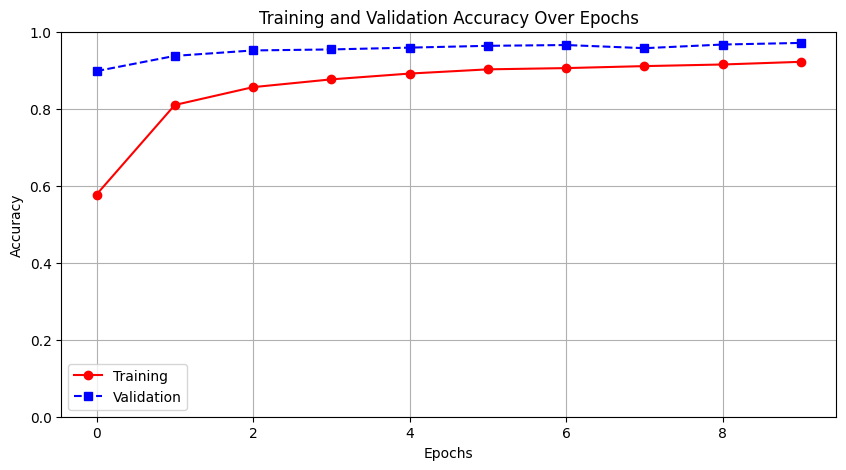

In [17]:
# graph of validation loss and training data accuracy
#x-axis represents the epochs, the y-axis represents the accuracy, and it
# shows both the training and validation accuracy.


import matplotlib.pyplot as plt

plt.figure(1, figsize=(10, 5))

# Plot the training accuracy with a red line, solid line style, and circle marker
plt.plot(model_1_history.history['accuracy'], color='red', linestyle='-', marker='o', label='Train')

# Plot the validation accuracy with a blue line, dashed line style, and square marker
plt.plot(model_1_history.history['val_accuracy'], color='blue', linestyle='--', marker='s', label='Validation')

# Set labels for x and y axis
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
#set the plot title
plt.title('Training and Validation Accuracy Over Epochs')

# Add grid lines
plt.grid(True)

# Limit y-axis range
plt.ylim(0, 1)

# Add a legend
plt.legend(['Training', 'Validation'])

# Show the plot
plt.show()

In [18]:
#image classification

model = Sequential([layers.Rescaling(1./255),])

#Layer1
model.add(Convolution2D(filters = 32,
			kernel_size = (3,3),
			strides = 1,
			activation = "relu",
			input_shape = (32,32,1)))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),
			strides=(2, 2),
			padding="same"))

#Layer2
model.add(Convolution2D(filters = 32,
			kernel_size = (3,3),
			strides = 1,
			activation = "relu",
			input_shape = (32,32,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),
			strides=(2, 2),
			padding="same"))


#Layers 3
model.add(Convolution2D(filters = 64,
			kernel_size = (3,3),
			strides = 1,
			activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),
			strides=(2, 2),
			padding="same"))


#Layer 4
model.add(Convolution2D(filters = 64,
			kernel_size = (3,3),
			strides= 1,
			activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),
			strides=(2, 2),
			padding="same"))
model.add(Flatten())

#Fully Connected Layer 1
model.add(Dense(128,
		activation = "relu",
		kernel_initializer = "uniform"))
model.add(BatchNormalization())

#Fully Connected Layer 2
model.add(Dense(64,
		activation = "relu",
		kernel_initializer = "uniform"))
model.add(BatchNormalization())

#Fully Connected Layer 3
model.add(Dense(46,
		activation = "softmax",
		kernel_initializer = "uniform"))

In [19]:
# Compile Model
model.compile(loss = 'categorical_crossentropy',
                optimizer = 'adam',
                metrics = ['accuracy'])

In [20]:
# Model fitting on the loaded dataset
# During each epoch, the model learns from the training dataset and evaluates
#its performance on the validation data.
model_history = model.fit(training_dataset,
                              validation_data = testting_dataset,
                        epochs = 10,)

Epoch 1/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 73s 28ms/step - accuracy: 0.7414 - loss: 1.1166 - val_accuracy: 0.9308 - val_loss: 0.2228
Epoch 2/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 69s 28ms/step - accuracy: 0.9532 - loss: 0.1570 - val_accuracy: 0.9598 - val_loss: 0.1347
Epoch 3/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 68s 28ms/step - accuracy: 0.9667 - loss: 0.1081 - val_accuracy: 0.9778 - val_loss: 0.0756
Epoch 4/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 71s 29ms/step - accuracy: 0.9734 - loss: 0.0837 - val_accuracy: 0.9519 - val_loss: 0.1649
Epoch 5/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 70s 28ms/step - accuracy: 0.9796 - loss: 0.0656 - val_accuracy: 0.9799 - val_loss: 0.0715
Epoch 6/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 69s 28ms/step - accuracy: 0.9813 - loss: 0.0588 - val_accuracy: 0.9801 - val_loss: 0.0691
Epoch 7/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 69s 28ms/step - accuracy: 0.9835 - loss: 0.0503 - val_accuracy: 0.9806 - val_loss: 0.0678
Epoch 8/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 71s 29ms/step - accuracy: 0.9849 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Actual_class : छ
Predicted Class :  क


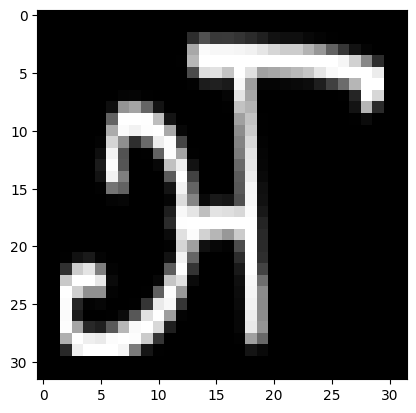

In [21]:
import cv2
import matplotlib.pyplot as plt
test_img = cv2.imread('DevanagariHandwrittenCharacterDataset/Test/character_10_yna/10544.png')
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.show()
test_img = cv2.resize(test_img,(32,32))
test_input = test_img.reshape((1,32,32,3))
predicted_probability = model.predict(test_input, verbose=1)
predicted_class = predicted_probability.argmax(axis=1)
class_number = predicted_class[0]
print('Actual_class : ञ')
print('Predicted Class : ', hindi_character[class_number])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Actual_class : 1
Predicted Class :  क


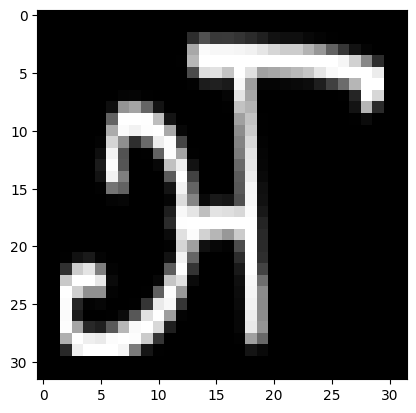

In [23]:
test_img_2 = cv2.imread('DevanagariHandwrittenCharacterDataset/Test/character_10_yna/10544.png')
plt.imshow(cv2.cvtColor(test_img_2, cv2.COLOR_BGR2RGB))
plt.show()
test_img_2 = cv2.resize(test_img_2,(32,32))
test_input = test_img_2.reshape((1,32,32,3))
predicted_probability = model.predict(test_input, verbose=1)
predicted_class = predicted_probability.argmax(axis=1)
class_number = predicted_class[0]
print('Actual_class : ञ')
print('Predicted Class : ', hindi_character[class_number])
